# PDAT 615 Module 5 Assignment
# Gracie Lovell
# September 13th, 2026

## Import Libraries

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

## Original Dataset
Plant Disease Detection Dataset: https://www.kaggle.com/datasets/mgmitesh/plant-disease-detection-dataset

## Load and Transfrom Dataset

In [47]:
train_dir = "plants/train"
test_dir = "plants/test"

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(
    train_dir,
    transform = transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform = transform
)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Classes: ['Apple', 'Cherry', 'Corn', 'Grape', 'Peach', 'Pepper', 'Potato', 'Strawberry', 'Tomato']
Training samples: 49984
Testing samples: 12494


In [48]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 64
)

## Define Model

In [49]:
class ModifiedLeNet5(nn.Module):
    def __init__(self):
        super(ModifiedLeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.bn1 = nn.BatchNorm2d(6)
        self.pool1 = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 9)

    def forward(self, x):
        x = torch.tanh(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = torch.tanh(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = x.view(-1, 16 * 4 * 4)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

## Define Loss and Optimizer

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = ModifiedLeNet5().to(device)

Using device: cpu


In [51]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

## Train the Model

In [52]:
num_epochs = 10
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    test_loss = 0.0
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            y_pred.append(preds.numpy())
            y_true.append(y_batch.numpy())
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    y_pred_all = np.concatenate(y_pred)
    y_true_all = np.concatenate(y_true)
    
    print(f"Epoch {epoch + 1} / {num_epochs}, Train Loss: {avg_loss:.4f}, "
          f"Test Loss: {test_loss:.4f}")

Epoch 1 / 10, Train Loss: 0.9956, Test Loss: 0.7246
Epoch 2 / 10, Train Loss: 0.5969, Test Loss: 0.4945
Epoch 3 / 10, Train Loss: 0.4411, Test Loss: 0.4337
Epoch 4 / 10, Train Loss: 0.3632, Test Loss: 0.3857
Epoch 5 / 10, Train Loss: 0.3127, Test Loss: 0.3208
Epoch 6 / 10, Train Loss: 0.2775, Test Loss: 0.3277
Epoch 7 / 10, Train Loss: 0.2463, Test Loss: 0.2999
Epoch 8 / 10, Train Loss: 0.2276, Test Loss: 0.2951
Epoch 9 / 10, Train Loss: 0.2052, Test Loss: 0.3277
Epoch 10 / 10, Train Loss: 0.1900, Test Loss: 0.2663


In [53]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 91.40%


## Plot Loss

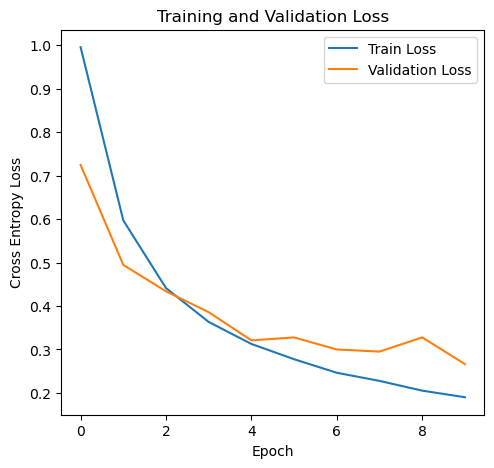

In [54]:
plt.figure(figsize = (12,5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label = 'Train Loss')
plt.plot(test_losses, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('Training and Validation Loss')
plt.legend()

## Strengths and Limitations

The first and most obvious strength is that the model performs very well with a 91.40% accuracy. I believe this performance can be attributed to the architecture of the model. The use of Batch Normalization makes training more stable, while the Adam optimizer allows the model to converge quickly. The overall structure of the model is relatively small and is able to distinguish between multiple plants and their diseases. On the other hand, the images are sized down to 28x28, which can remove some of the finer details in the images. Furthermore, the original design of this model was created for greyscale images, so this model now has 3 input channels instead of 1 to allow the use of color information.

## Short Reflection

The model developed in this assignment is a modified version of the LeNet-5 model. The main change made to this architecture was the addition of Batch Normalization after each convolutional layer. This addition was implemented to help stabilize the training process and improve the model's ability to identify plants and their corresponding diseases. Furthermore, the images contained in this dataset are in color, not greyscale, therefore the number of input channels have been changed to three (red, green, blue). These small modifications to LeNet-5 allow for the model to work more complex computer vision dataset.

This plant disease detection model can have several real-world applications in farming and agriculture. For example, this system could allow farmers or agronomists to upload a picture of a plant or crop and receive a prediction about the species of plant or what disease may be present within that plant. This could allow for plant diseases to be identified more quickly, which would allow for infected plants to be treated faster and more efficiently. This could also serve as a learning aid for people new to the field of botany or agronomy. They could receive instant information in the field about the plants and what diseases could affect them. Overall, this model can be very useful in many different ways.